Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from  sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Load the Dataset

In [60]:
df = pd.read_csv(r"E:\Data Science classes\Assignments\Questions\16. Recommendation System\anime.csv")

print("Shape:", df.shape)
print("First 10 Rows:")
print(df.head(10))

Shape: (12294, 7)
First 10 Rows:
   anime_id                                               name  \
0     32281                                     Kimi no Na wa.   
1      5114                   Fullmetal Alchemist: Brotherhood   
2     28977                                           Gintama°   
3      9253                                        Steins;Gate   
4      9969                                      Gintama&#039;   
5     32935  Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...   
6     11061                             Hunter x Hunter (2011)   
7       820                               Ginga Eiyuu Densetsu   
8     15335  Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...   
9     15417                           Gintama&#039;: Enchousen   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [62]:
df.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
anime_id,12294.0,NaN,NaN,NaN,14058.22,11455.29,1.0,3484.25,10260.5,24794.5,34527.0
name,12294,12292,Saru Kani Gassen,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,12232,3264,Hentai,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,12269,6,TV,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
episodes,12294,187,1,5677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,12064.0,NaN,NaN,NaN,6.47,1.03,1.67,5.88,6.57,7.18,10.0
members,12294.0,NaN,NaN,NaN,18071.34,54820.68,5.0,225.0,1550.0,9437.0,1013917.0


In [63]:
#Checking Missing Values
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total Missing Values:', df.isnull().sum().sum())

Missing values per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Total Missing Values: 317


In [64]:
#unique Values in categorical columns

print("Unique types:")
print(df['type'].value_counts())

print('simple gernes:')
print(df['genre'].dropna().head(10).values)

Unique types:
type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64
simple gernes:
['Drama, Romance, School, Supernatural'
 'Action, Adventure, Drama, Fantasy, Magic, Military, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Sci-Fi, Thriller'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Comedy, Drama, School, Shounen, Sports'
 'Action, Adventure, Shounen, Super Power'
 'Drama, Military, Sci-Fi, Space'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen']


Data Processing

In [65]:
df_clean = df.copy()

df_clean['genre'] = df_clean['genre'].fillna('')

df_clean['type'] = df_clean['type'].fillna('Unknown')

median_ratings = df_clean['rating'].median()
df_clean['rating'] = df_clean['rating'].fillna(median_ratings)
print(f'Filled the missing values in ratings column with the Median: {median_ratings: .2f}')

df_clean['episodes']= pd.to_numeric(df_clean['episodes'], errors='coerce')
median_eps = df_clean['episodes'].median()
df_clean['episodes'] = df_clean['episodes'].fillna(median_eps)
print(f'Filled missing episodes with median: {median_eps}')

import html
df_clean['name']= df_clean['name'].apply(html.unescape)

df_clean = df_clean.reset_index(drop=True)

print(f'cleaned dataset shape : {df_clean.shape}')
print('Remaining missing values:')
print(df_clean.isnull().sum())

Filled the missing values in ratings column with the Median:  6.57
Filled missing episodes with median: 2.0
cleaned dataset shape : (12294, 7)
Remaining missing values:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


Exploratory Data Analysis (EDA)

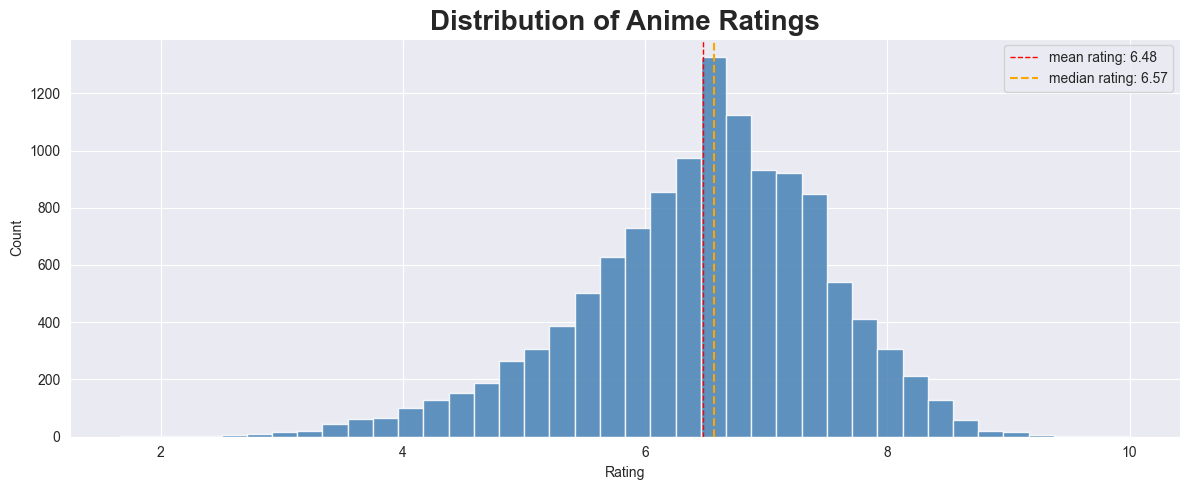

In [66]:
#Distribution of ratings
plt.figure(figsize=(12,5))
plt.hist(df_clean['rating'], bins=40, color= 'steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df_clean['rating'].mean(), color='red', linestyle='--', linewidth=1,
            label=f'mean rating: {df_clean["rating"].mean():.2f}')
plt.axvline(df_clean['rating'].median(), color = 'orange', linestyle='--',label=f'median rating: {df_clean["rating"].median():.2f}')
plt.title('Distribution of Anime Ratings', fontsize=20, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

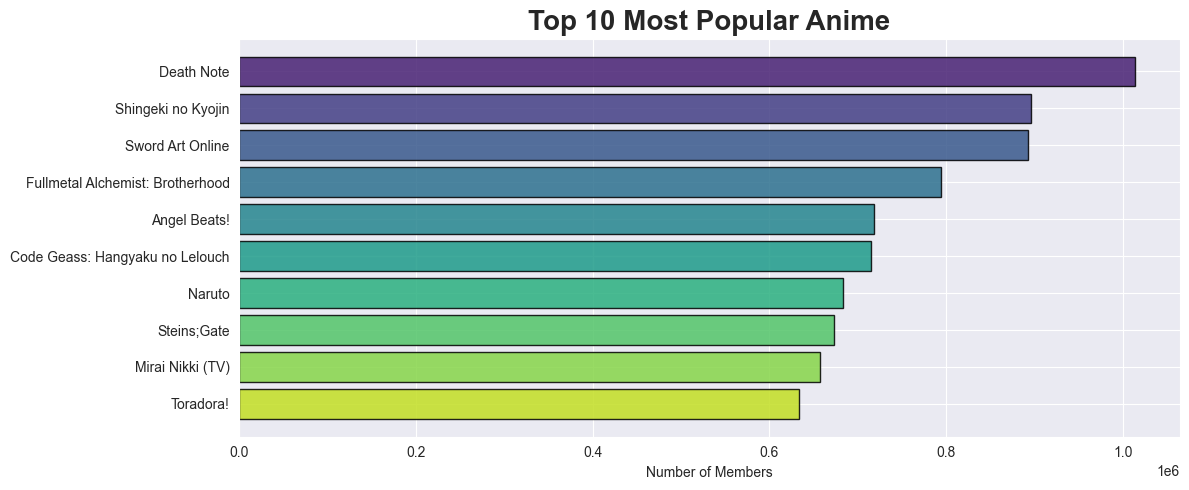

In [67]:
#Top 10 most popular anime by members

top_popular = df_clean.nlargest(10, 'members')[['name', 'members', 'rating']]

plt.figure(figsize=(12,5))
bars=plt.barh(top_popular['name'][::-1], top_popular['members'][::-1],
              color = sns.color_palette('viridis', 10)[::-1],edgecolor= 'black', alpha = 0.85)
plt.title('Top 10 Most Popular Anime', fontsize=20, fontweight='bold')
plt.xlabel('Number of Members')
plt.tight_layout()
plt.show()

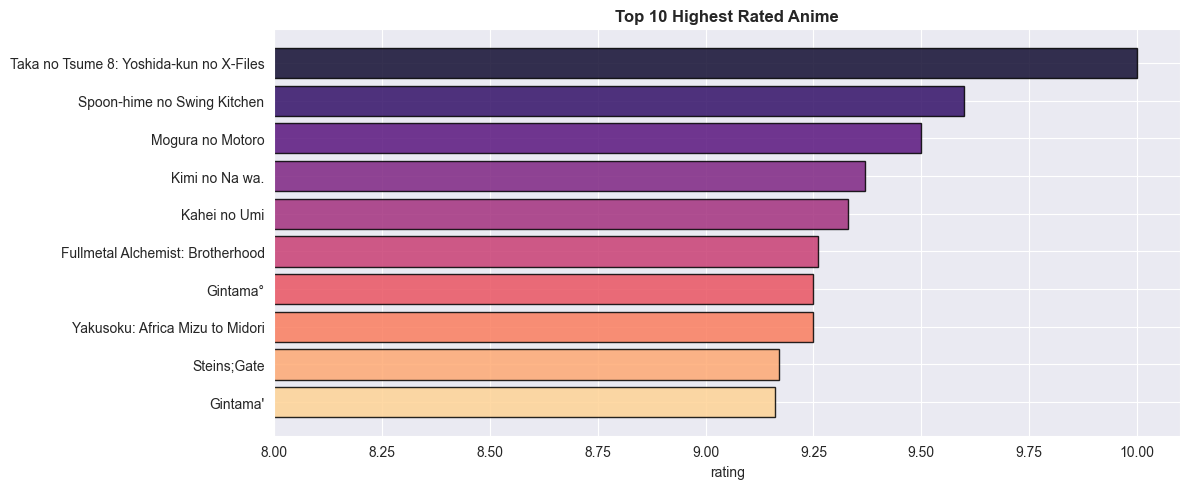

In [68]:
#Top 10 Highest Rated Anime
top_rated = df_clean.nlargest(10, 'rating')[['name', 'rating', 'members']]
plt.figure(figsize=(12,5))
plt.barh(top_rated['name'][::-1], top_rated['rating'][::-1],
         color = sns.color_palette('magma', 10)[::-1],edgecolor='black', alpha = 0.85)
plt.title('Top 10 Highest Rated Anime', fontweight='bold')
plt.xlabel('rating')
plt.xlim(8,10.1)
plt.tight_layout()
plt.show()

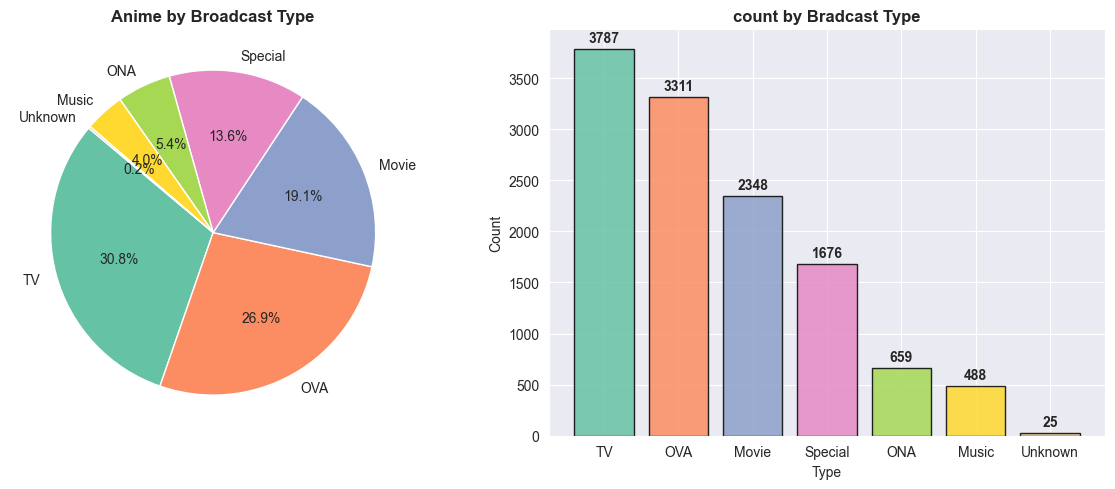

In [69]:
type_counts = df_clean['type'].value_counts()

fig,axes = plt.subplots(1,2,figsize=(12,5))

axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors = sns.color_palette('Set2', len(type_counts)), startangle = 140)
axes[0].set_title('Anime by Broadcast Type', fontweight='bold')

ax=axes[1].bar(type_counts.index,type_counts.values,
            color= sns.color_palette('Set2', len(type_counts)), edgecolor='black', alpha = 0.85)
for count in axes[1].containers:
    axes[1].bar_label(count, padding=3, fontweight='bold')
axes[1].set_title('count by Bradcast Type', fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].grid(True)
plt.tight_layout()
plt.show()

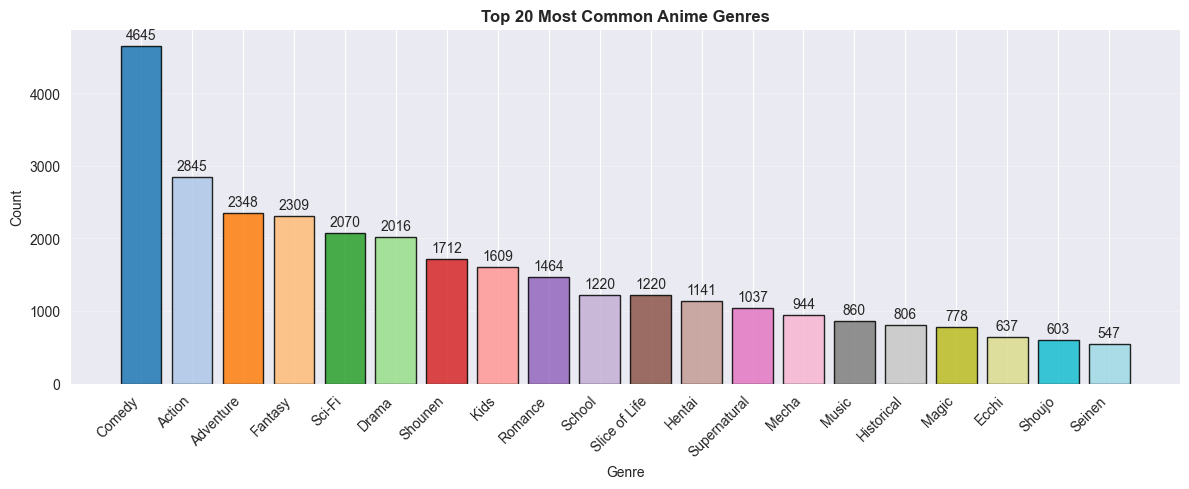

In [70]:
#Top 20 Most Common genres

all_genres = df_clean['genre'].str.split(',').explode().str.strip()
genre_counts = all_genres[all_genres != ''].value_counts().head(20)

plt.figure(figsize=(12,5))
ax=plt.bar(genre_counts.index, genre_counts.values,
        color = sns.color_palette('tab20',20), edgecolor='black', alpha = 0.85)
plt.gca().bar_label(ax, padding=3)
plt.title('Top 20 Most Common Anime Genres', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha= 'right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

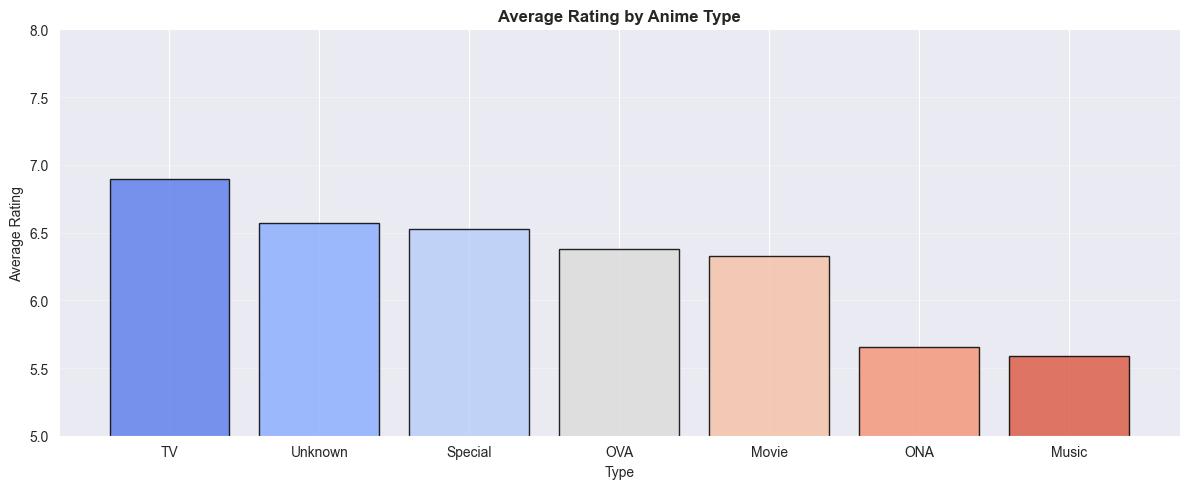

In [71]:
#Average rating by type

avg_rating_type = df_clean.groupby('type')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.bar(avg_rating_type.index, avg_rating_type.values,
        color = sns.color_palette('coolwarm', len(avg_rating_type)),edgecolor='black', alpha = 0.85)
plt.gca().bar_label(bars, padding=3, fontweight='bold', fmt='%.2f')
plt.title('Average Rating by Anime Type', fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Average Rating')
plt.ylim(5,8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

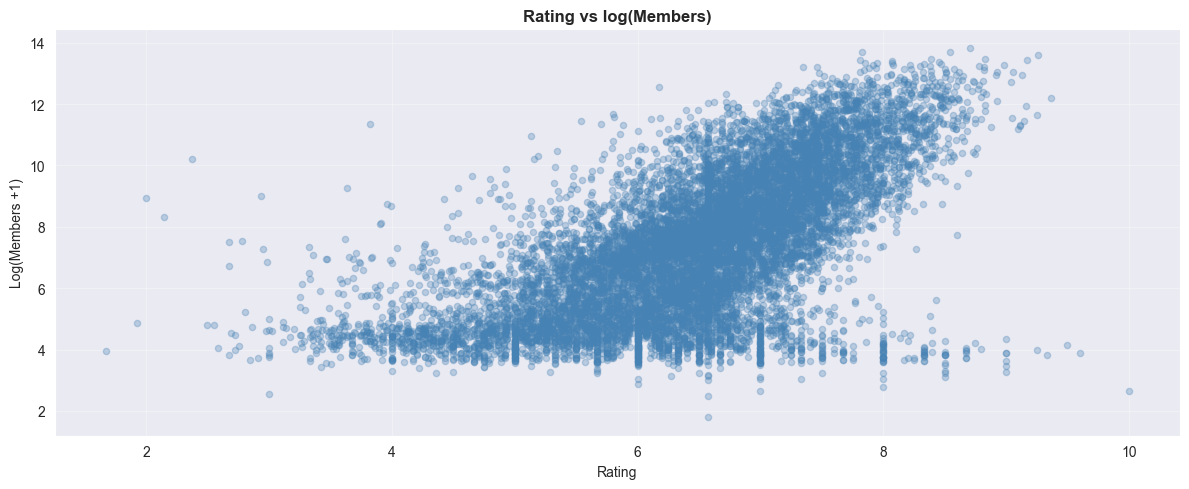

Correlation Matrix
          rating  members  episodes
rating      1.00     0.39      0.09
members     0.39     1.00      0.06
episodes    0.09     0.06      1.00


In [72]:
#Scatter: Members vs Ratings

plt.figure(figsize=(12,5))
plt.scatter(df_clean['rating'], np.log1p(df_clean['members']), alpha=0.3, s=20, color = 'steelblue')
plt.title('Rating vs log(Members)', fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Log(Members +1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_clean[['rating', 'members', 'episodes']].corr()
print('Correlation Matrix')
print(corr.round(2))

Feature Extraction

In [73]:
tfidf = TfidfVectorizer(tokenizer=lambda x: [g.strip() for g in x.split(',')],
                        token_pattern= None)
genre_matrix = tfidf.fit_transform(df_clean['genre'])

print('Genre TF-IDF matrix shape:', genre_matrix.shape)
print('Unique genres as features:', len(tfidf.get_feature_names_out()))
print('Feature Names (First 20):', tfidf.get_feature_names_out()[:20])

Genre TF-IDF matrix shape: (12294, 44)
Unique genres as features: 44
Feature Names (First 20): ['' 'action' 'adventure' 'cars' 'comedy' 'dementia' 'demons' 'drama'
 'ecchi' 'fantasy' 'game' 'harem' 'hentai' 'historical' 'horror' 'josei'
 'kids' 'magic' 'martial arts' 'mecha']


In [74]:
#encode Broadcast Type (one-Hot)
type_dummies = pd.get_dummies(df_clean['type'], prefix='type')
print('Type one-hot encoded shape:', type_dummies.shape)
print('Columns:', type_dummies.columns.tolist())

Type one-hot encoded shape: (12294, 7)
Columns: ['type_Movie', 'type_Music', 'type_ONA', 'type_OVA', 'type_Special', 'type_TV', 'type_Unknown']


In [75]:
#Normalize Numeric Features

scaler = MinMaxScaler()
numeric_cols = ['rating', 'members', 'episodes']
numeric_scaled = scaler.fit_transform(df_clean[numeric_cols])
numeric_df = pd.DataFrame(numeric_scaled, columns=numeric_cols)

print('Numeric Features scaled (first 5 rows)')
print(numeric_df.head())

Numeric Features scaled (first 5 rows)
     rating   members  episodes
0  0.924370  0.197872  0.000000
1  0.911164  0.782770  0.034673
2  0.909964  0.112689  0.027518
3  0.900360  0.664325  0.012658
4  0.899160  0.149186  0.027518


In [76]:
import scipy.sparse as sp

genre_weight = 3.0
numeric_weight = 1.0
type_weight = 0.5

genre_weighted = genre_matrix* genre_weight
numeric_sparse = sp.csr_matrix(numeric_df.values * numeric_weight)
type_sparse = sp.csr_matrix(type_dummies.values * type_weight)

feature_matrix = sp.hstack([genre_weighted, numeric_sparse, type_sparse])
print('Combined Feature Matrix shape:', feature_matrix.shape)

Combined Feature Matrix shape: (12294, 54)


Cosine Similarity Recommendation System

Compute Cosine Similarity Matrix

In [77]:
# Compute cosine similarity between all anime
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)

print('Cosine Similarity Matrix shape:', cosine_sim.shape)
print(f'Sample similarity (anime 0 vs anime 1): {cosine_sim[0, 1]:.4f}')
print(f'Self-similarity (should be 1.0): {cosine_sim[0, 0]:.4f}')

# Build a reverse index: anime name → row index
# Use the cleaned 'name' column
name_to_idx = pd.Series(df_clean.index, index=df_clean['name'].str.lower()).drop_duplicates()
print(f'\nIndex built for {len(name_to_idx)} anime.')

Cosine Similarity Matrix shape: (12294, 12294)
Sample similarity (anime 0 vs anime 1): 0.2233
Self-similarity (should be 1.0): 1.0000

Index built for 12294 anime.


Recommendation Function

In [78]:
def recommend_anime(anime_title, top_n =10, thershold = 0.0, sim_matrix = cosine_sim,
                    idx_map = name_to_idx, data = df_clean):
    title_lower = anime_title.lower()

    if title_lower not in idx_map:
        matches = [name for name in idx_map.index if title_lower in name]
        if matches:
            print(f"Exact match not found. using closest:'{matches[0]}'")
            title_lower = matches[0]
        else:
            print(f"Anime '{anime_title}' not found in dataset.")
            return None

    idx = idx_map[title_lower]
    sim_scores = list(enumerate(sim_matrix[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx and s>thershold]
    sim_scores = sim_scores[:top_n]

    result_indices = [i for i, _ in sim_scores]
    result_scores = [round(s,4) for _, s in sim_scores]

    result = data.loc[result_indices, ['name', 'genre', 'type', 'rating', 'members']].copy()
    result.insert(0, 'similarity_score', result_scores)
    result = result.reset_index(drop = True)
    result.index +=1

    return result

Test of Recommendation System

In [79]:
print('Recommendation for: Fullmetal Alchemist: Brotherhood')
recs1= recommend_anime('Fullmetal Alchemist: Brotherhood', top_n = 10)
print(recs1.to_string())

Recommendation for: Fullmetal Alchemist: Brotherhood
    similarity_score                                           name                                                                genre     type  rating  members
1             0.9750                            Fullmetal Alchemist  Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen       TV    8.33   600384
2             0.9271  Fullmetal Alchemist: The Sacred Star of Milos  Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen    Movie    7.50    87944
3             0.9117      Fullmetal Alchemist: Brotherhood Specials                  Adventure, Drama, Fantasy, Magic, Military, Shounen  Special    8.11    67962
4             0.8353            Tales of Vesperia: The First Strike                          Action, Adventure, Fantasy, Magic, Military    Movie    7.79    30524
5             0.8204                                 Tide-Line Blue                          Action, Adventure, Drama, Military, Sho

In [80]:
print('Recommendation for: Steins;Gate')
recs2= recommend_anime('Steins;Gate', top_n = 10)
print(recs2.to_string())

Recommendation for: Steins;Gate
    similarity_score                                                         name                               genre     type  rating  members
1             0.9647                   Steins;Gate Movie: Fuka Ryouiki no Déjà vu                    Sci-Fi, Thriller    Movie    8.61   192424
2             0.9630                        Steins;Gate: Oukoubakko no Poriomania                    Sci-Fi, Thriller  Special    8.46   159548
3             0.9562  Steins;Gate: Kyoukaimenjou no Missing Link - Divide By Zero                    Sci-Fi, Thriller  Special    8.34    38147
4             0.9531                                                Steins;Gate 0                    Sci-Fi, Thriller  Unknown    6.57    60999
5             0.8939                                                Under the Dog            Action, Sci-Fi, Thriller      OVA    6.55    29922
6             0.8648                                  Kyoto Animation: Megane-hen                       

In [81]:
print('Recommendation for: Kimi no Na wa.')
recs3= recommend_anime('Kimi no Na wa.', top_n = 10)
print(recs3.to_string())

Recommendation for: Kimi no Na wa.
    similarity_score                                   name                                                  genre     type  rating  members
1             0.9664            Wind: A Breath of Heart OVA                   Drama, Romance, School, Supernatural      OVA    6.35     2043
2             0.9656           Wind: A Breath of Heart (TV)                   Drama, Romance, School, Supernatural       TV    6.14     7778
3             0.9561  Aura: Maryuuin Kouga Saigo no Tatakai           Comedy, Drama, Romance, School, Supernatural    Movie    7.67    22599
4             0.8800                               Harmonie                            Drama, School, Supernatural    Movie    7.52    29029
5             0.8646                              Air Movie                           Drama, Romance, Supernatural    Movie    7.39    44179
6             0.8565         Angel Beats!: Another Epilogue                            Drama, School, Supernatural  Spe

Experoment with similarity threshold

Effect of threshold on recommendation for: Steins;Gate
--------------------------------------------------
   Threshold |   Recommendation Returned
--------------------------------------------------
         0.0 |                        10 
         0.2 |                        10 
         0.4 |                        10 
         0.6 |                        10 
         0.8 |                         8 


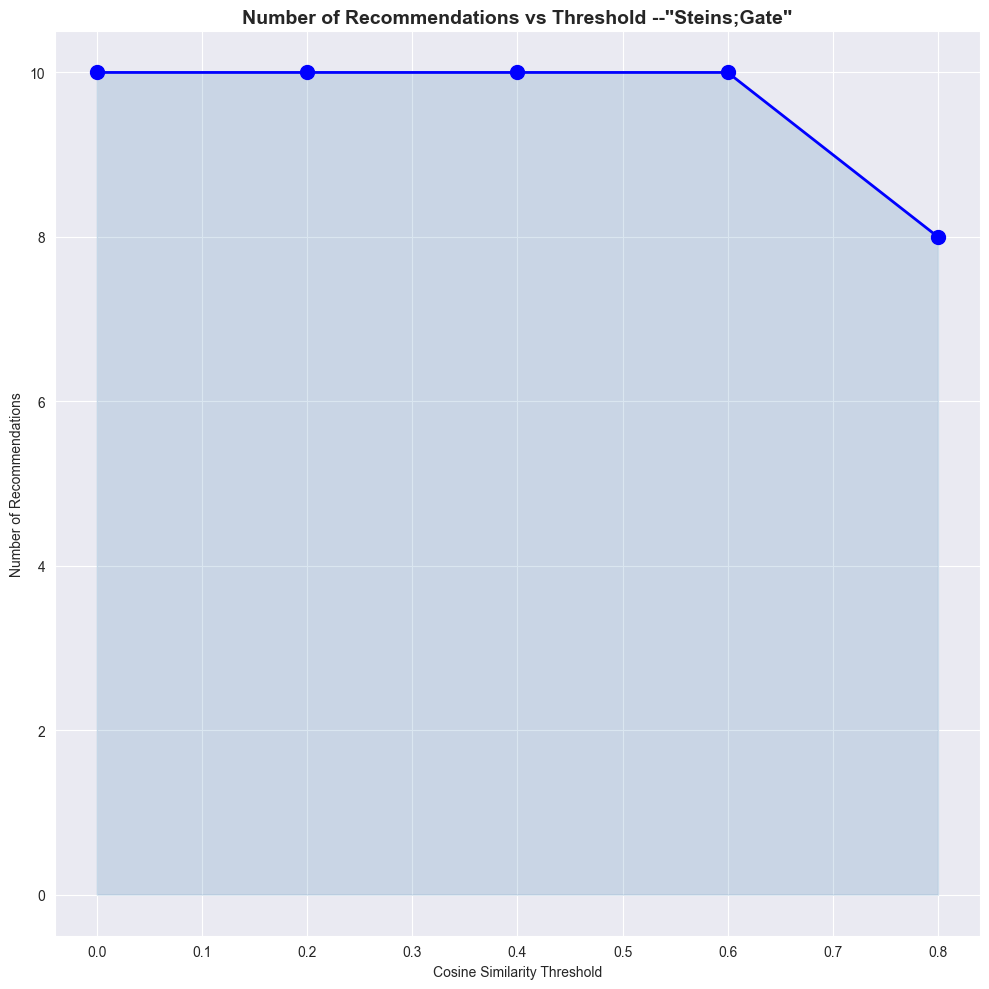

In [82]:
thresholds = [0.0, 0.2, 0.4, 0.6, 0.8]
target_anime = 'Steins;Gate'

print(f"Effect of threshold on recommendation for: {target_anime}")
print('-'*50)
print(f'{"Threshold": >12} | {"Recommendation Returned":>25}' )
print('-'*50)

threshold_counts = []
for t in thresholds:
    recs = recommend_anime(target_anime, top_n = 10, thershold=t)
    count = len(recs) if recs is not None else 0
    threshold_counts.append(count)
    print(f'{t:>12.1f} | {count:>25} ')


plt.figure(figsize = (10,10))
plt.plot(thresholds, threshold_counts, 'bo-', markersize = 10, lw=2)
plt.fill_between(thresholds, threshold_counts, alpha = 0.2, color = 'steelblue')
plt.title(f'Number of Recommendations vs Threshold --"{target_anime}"', fontsize = 14, fontweight = 'bold')
plt.xlabel('Cosine Similarity Threshold')
plt.ylabel('Number of Recommendations')
plt.grid(True)
plt.tight_layout()
plt.show()

Visualization of Recommendations

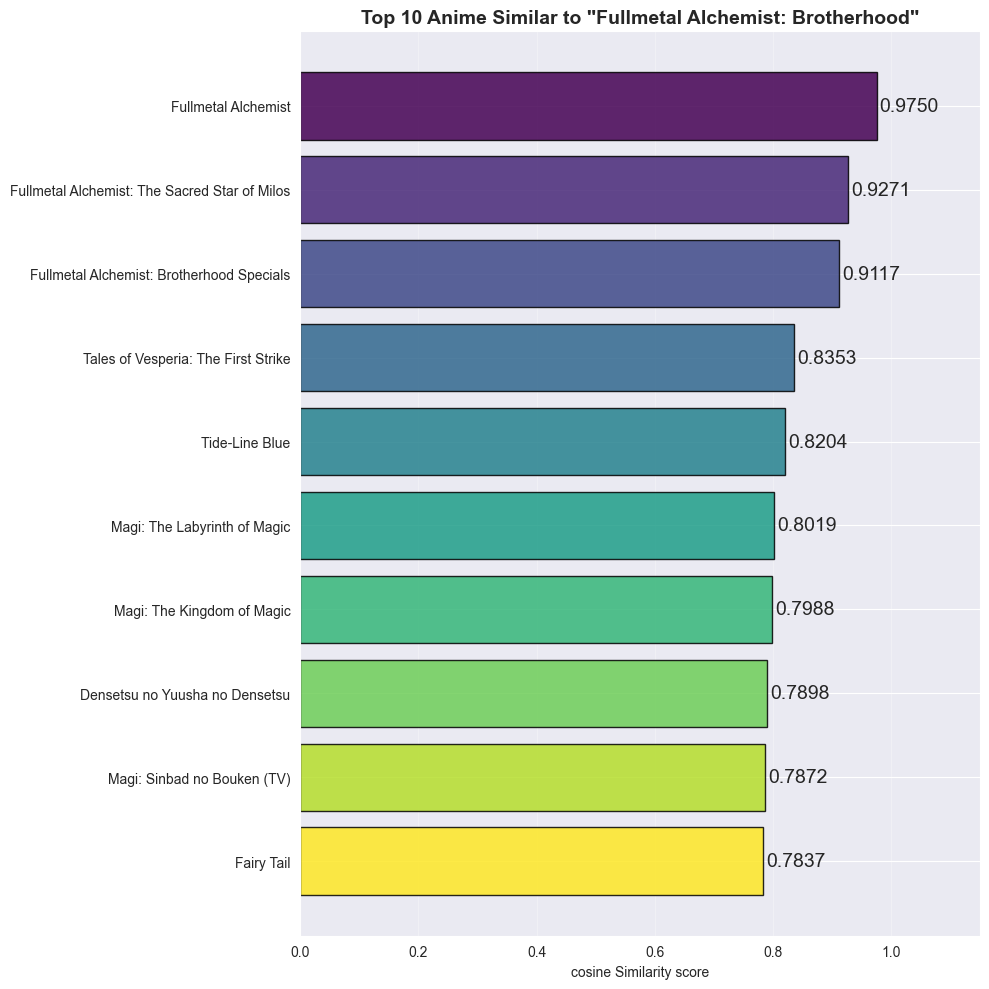

In [83]:
def plot_recommendations(anime_title, top_n = 10, threshold = 0.0):
    recs = recommend_anime(anime_title, top_n = top_n, thershold= threshold)
    if recs is None:
        return

    plt.figure(figsize = (10,10))
    colors = plt.cm.viridis(np.linspace(0,1,len(recs)))
    bars = plt.barh(recs['name'][::-1], recs['similarity_score'][::-1], color = colors[::-1],
                    edgecolor = 'black', alpha = 0.85)

    for bar, val in zip(bars, recs['similarity_score'][::-1]):
        plt.text(bar.get_width()+0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va = 'center', fontsize = 14)

    plt.title(f'Top {top_n} Anime Similar to "{anime_title}"', fontsize = 14, fontweight = 'bold')
    plt.xlabel('cosine Similarity score')
    plt.xlim(0,1.15)
    plt.grid(True, alpha = 0.3, axis = 'x')
    plt.tight_layout()
    plt.show()

plot_recommendations('Fullmetal Alchemist: Brotherhood', top_n = 10)

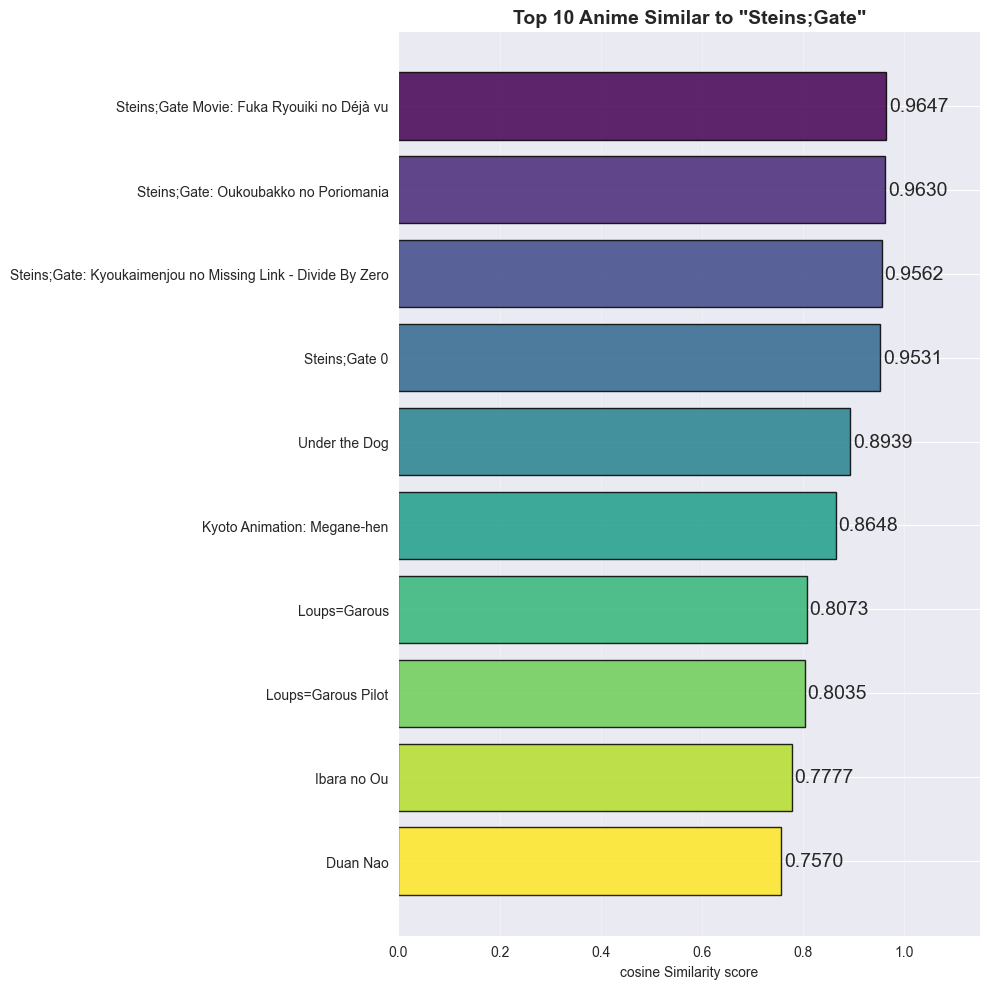

In [84]:
plot_recommendations('Steins;Gate', top_n = 10)

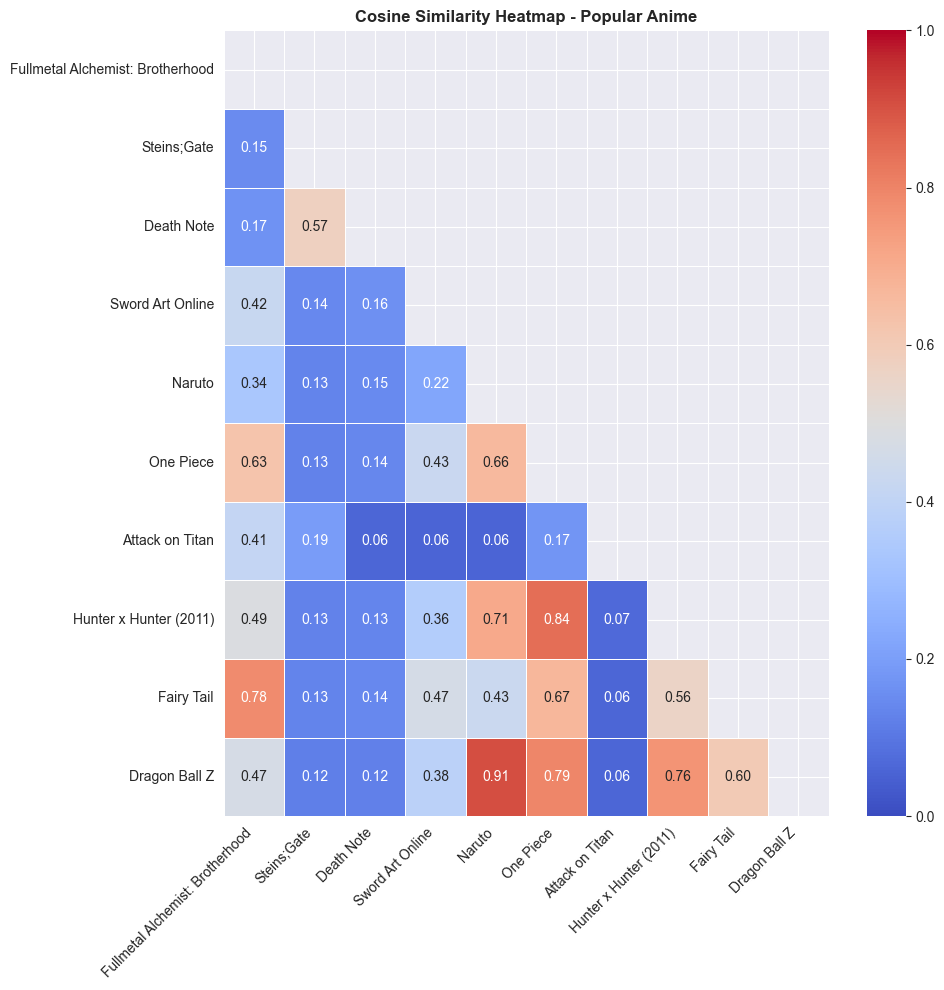

In [85]:
popular_titles = [
    'Fullmetal Alchemist: Brotherhood',
    'Steins;Gate',
    'Death Note',
    'Sword Art Online',
    'Naruto',
    'One Piece',
    'Attack on Titan',
    'Hunter x Hunter (2011)',
    'Fairy Tail',
    'Dragon Ball Z'
]

valid_titles = []
valid_indices = []
for t in popular_titles:
    key = t.lower()
    if key in name_to_idx:
        valid_titles.append(t)
        valid_indices.append(name_to_idx[key])

    else:
        matches = [n for n in name_to_idx.index if t.lower().split()[0] in n]
        if matches:
            valid_titles.append(t)
            valid_indices.append(name_to_idx[matches[0]])

if len(valid_indices) >= 2:
    sim_subset = cosine_sim[np.ix_(valid_indices, valid_indices)]

    plt.figure(figsize = (10,10))
    mask = np.triu(np.ones_like(sim_subset, dtype = np.bool))
    sns.heatmap(sim_subset, xticklabels= valid_titles, yticklabels=valid_titles,
                annot = True, cmap = 'coolwarm',mask =mask, fmt ='.2f', lw=0.5, vmin = 0, vmax = 1)
    plt.title('Cosine Similarity Heatmap - Popular Anime', fontweight ='bold')
    plt.xticks(rotation = 45, ha = 'right')
    plt.yticks(rotation = 0)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough titles found for heatmap.')

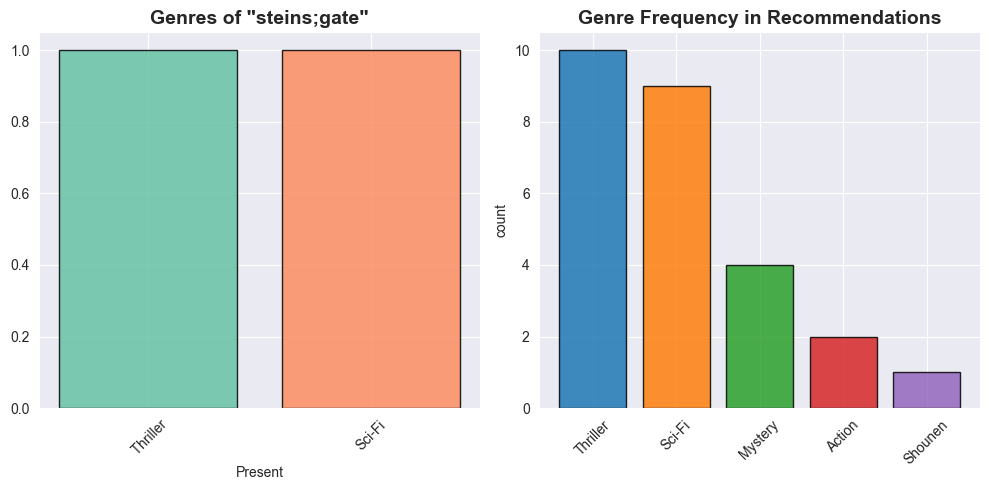

In [86]:
def compare_genres(anime_title, top_n =10):
    recs = recommend_anime(anime_title, top_n = top_n)
    if recs is None:
        return

    idx = name_to_idx.get(anime_title.lower())
    orig_genres =set(df_clean.loc[idx, 'genre'].split(','))

    rec_genres = recs['genre'].str.split(',').explode().str.strip()
    rec_genre_counts = rec_genres.value_counts().head()

    fig, axes = plt.subplots(1,2, figsize = (10,5))
    orig_list = [g for g in orig_genres if g]
    axes[0].bar(orig_list, [1]* len(orig_list),
                color = sns.color_palette('Set2', len(orig_list)), edgecolor = 'black', alpha = 0.85)
    axes[0].set_title(f'Genres of "{anime_title}"', fontsize = 14, fontweight = 'bold')
    axes[0].set_xlabel('Present')
    axes[0].tick_params(axis ='x', rotation =45)


    axes[1].bar(rec_genre_counts.index, rec_genre_counts.values,
                color = sns.color_palette('tab10', len(rec_genre_counts)), edgecolor = 'black', alpha = 0.85)
    axes[1].set_title('Genre Frequency in Recommendations', fontsize = 14, fontweight = 'bold')
    axes[1].set_ylabel('count')
    axes[1].tick_params(axis='x', rotation =45)

    plt.tight_layout()
    plt.show()

compare_genres('steins;gate')

Performance Analysis

In [87]:
test_anime_list = [
    'Fullmetal Alchemist: Brotherhood',
    'Steins;Gate',
    'Kimi no Na wa.',
    'Death Note',
    'Sword Art Online',
]

print(f'{"Anime":<40} {"Top-10 Avg Similarity": >22} {"Max Similarity": >16}')
print('-'*80)

for anime in test_anime_list:
    recs = recommend_anime(anime, top_n = 10)
    if recs is not None and len(recs) > 0:
        avg_sim = recs['similarity_score'].mean()
        max_sim = recs['similarity_score'].max()
        print(f'{anime:<40} {avg_sim:>22.4f} {max_sim:>16.4f}')

Anime                                     Top-10 Avg Similarity   Max Similarity
--------------------------------------------------------------------------------
Fullmetal Alchemist: Brotherhood                         0.8431           0.9750
Steins;Gate                                              0.8741           0.9647
Kimi no Na wa.                                           0.8905           0.9664
Death Note                                               0.8213           0.9368
Sword Art Online                                         0.8673           0.9943


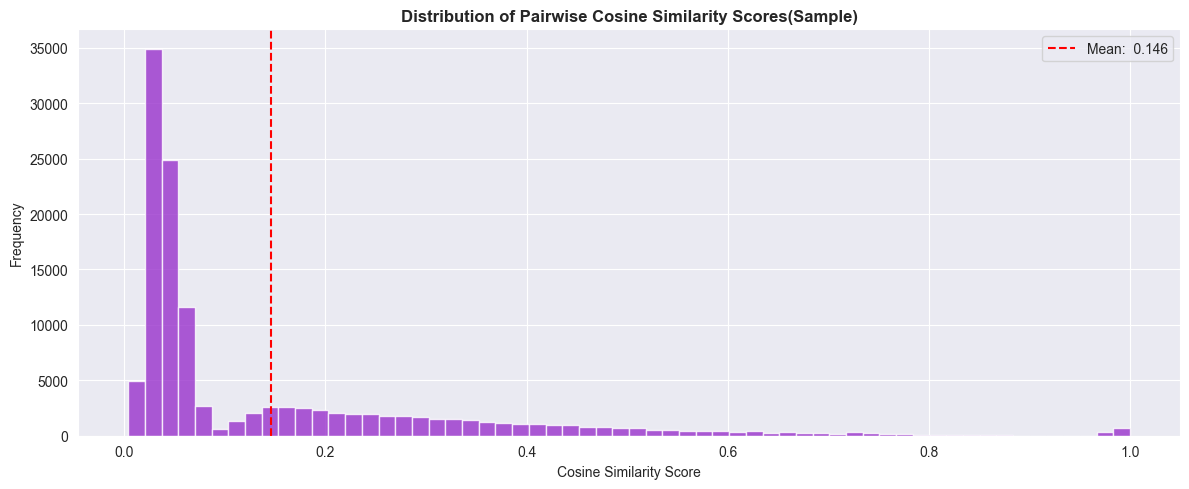

Mean pairwise Similarity: 0.1463
Median pairwise similarity: 0.0509
% Pairs with similarity > 0.5: 6.1%
% pairs with similarity > 0.8: 1.2%


In [88]:
np.random.seed(42)
sample_n= 500
sample_rows = np.random.choice(len(df_clean), sample_n, replace = False)
sim_sample = cosine_sim[np.ix_(sample_rows, sample_rows)]

upper_tri = sim_sample[np.triu_indices(sample_n, k=1)]

plt.figure(figsize = (12,5))
plt.hist(upper_tri, bins = 60, color ='darkorchid', edgecolor = 'white', alpha=0.8)
plt.title('Distribution of Pairwise Cosine Similarity Scores(Sample)', fontweight ='bold')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency')
plt.axvline(upper_tri.mean(), color='red', linestyle='dashed', label = f'Mean: {upper_tri.mean(): .3f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Mean pairwise Similarity: {upper_tri.mean():.4f}')
print(f'Median pairwise similarity: {np.median(upper_tri):.4f}')
print(f'% Pairs with similarity > 0.5: {100*(upper_tri > 0.5).mean():.1f}%')
print(f'% pairs with similarity > 0.8: {100*(upper_tri > 0.8).mean():.1f}%')

Top 10 recommendations for "Naruto" (thershold = 0.3):
    similarity_score                                                                       name                                                                   genre     type  rating  members
1             0.9982                                                         Naruto: Shippuuden                      Action, Comedy, Martial Arts, Shounen, Super Power       TV    7.94   533578
2             0.9571                                Naruto: Shippuuden Movie 4 - The Lost Tower                      Action, Comedy, Martial Arts, Shounen, Super Power    Movie    7.53    84527
3             0.9570                      Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono                      Action, Comedy, Martial Arts, Shounen, Super Power    Movie    7.50    83515
4             0.9567                                                   Boruto: Naruto the Movie                      Action, Comedy, Martial Arts, Shounen, Super Power  

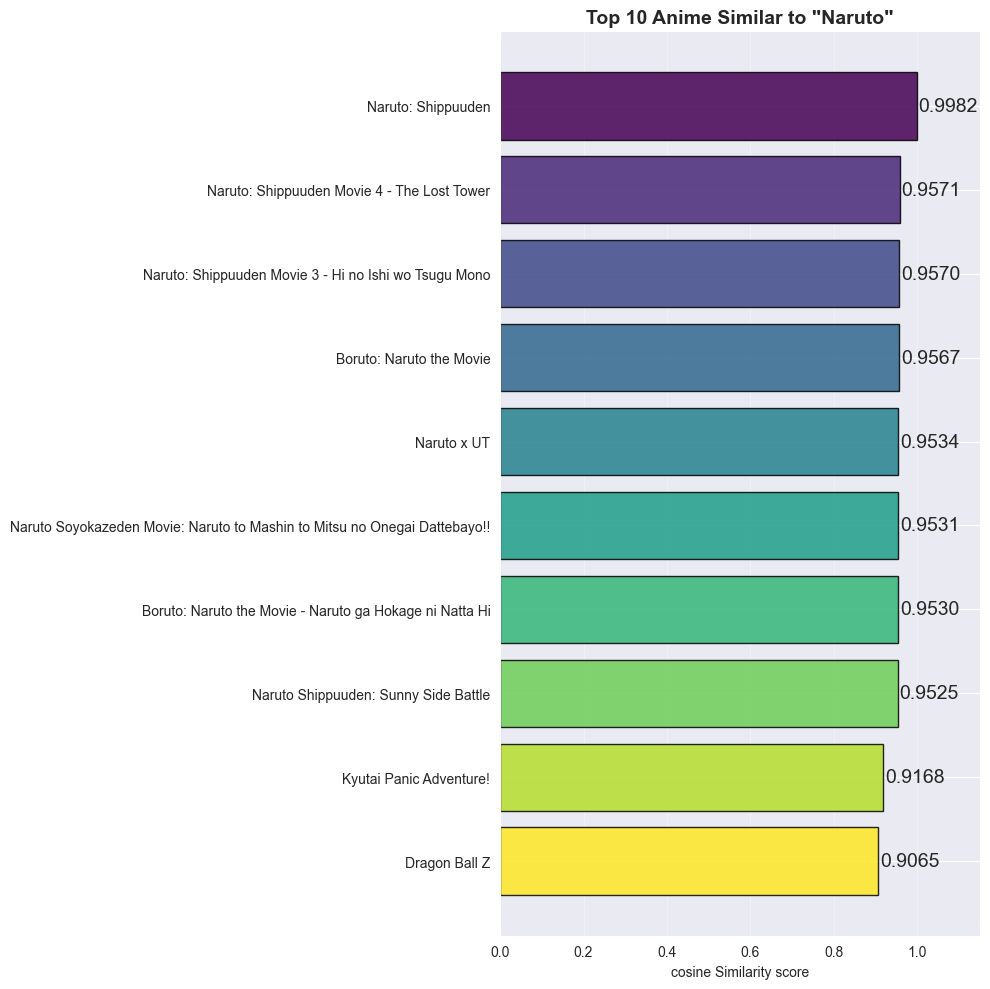

In [89]:
anime_query = 'Naruto'
top_n = 10
threshold = 0.3

result = recommend_anime(anime_query, top_n = top_n, thershold = threshold)
if result is not None:
    print(f'Top {top_n} recommendations for "{anime_query}" (thershold = {threshold}):')
    print(result.to_string())
    plot_recommendations(anime_query, top_n = top_n, threshold = threshold)

In [90]:
import pickle
pickle.dump(df_clean, open('anime_list.pkl', 'wb'))
pickle.dump(cosine_sim, open('similarity.pkl', 'wb'))


In [91]:
appcode = """
import html
import pickle
import numpy as np
import pandas as pd
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Page Configuration
st.set_page_config(page_title="Anime Recommendation System", layout="centered")
st.title("🎬 Anime Recommendation System")

# 2. Load the Pickled Dataframe & Compute TF-IDF Matrix (Cached for speed)
@st.cache_data
def load_and_process_data():
    with open("anime_list.pkl", "rb") as f:
        df_clean = pickle.load(f)

    # Re-create the TF-IDF Vectorizer on the genre column (just like your notebook)
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(df_clean['genre'])

    return df_clean, tfidf_matrix

try:
    df, tfidf_matrix = load_and_process_data()

    # 3. Dropdown Menu for Selection
    anime_list = df["name"].values
    selected_anime = st.selectbox(
        "Type or select an anime you like:", anime_list
    )

    # 4. Recommendation Logic (Triggered on Button Click)
    if st.button("Recommend"):
        st.subheader(f"Because you watched '{selected_anime}':")

        # Find the index of the selected anime
        idx = df[df['name'] == selected_anime].index[0]

        # DYNAMIC CALCULATION: Compute cosine similarity only for the SELECTED anime
        # against the entire matrix. This keeps memory usage low and runs instantly.
        sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

        # Get the top 11 most similar anime indices (including itself)
        similar_indices = np.argsort(sim_scores)[::-1][:11]

        # Filter out the selected anime itself and pick the top 5 distinct recommendations
        recommended_anime = []
        for i in similar_indices:
            if df.iloc[i]['name'] != selected_anime:
                recommended_anime.append(df.iloc[i])
            if len(recommended_anime) == 5:
                break

        # 5. Display Recommendations
        for anime in recommended_anime:
            # Unescape any remaining HTML characters (e.g., &#039; to ')
            clean_name = html.unescape(anime['name'])
            st.write(f"⭐ **{clean_name}** | Type: *{anime['type']}* | Rating: `{anime['rating']}`")

except FileNotFoundError:
    st.error("Error: 'anime_list.pkl' not found. Please ensure it is in your root directory.")
"""
with open('Recommendation_system.py', 'w', encoding='utf-8') as f:
    f.write(appcode)

print('Recommendation System app is ready.')

Recommendation System app is ready.
